In [1]:
import numpy as np
import pickle
import warnings

In [29]:
with open('card_game/eda_results/eda_trial8.pkl', 'rb') as f:
    results = pickle.load(f)
pf = results['converged_pf_table'][-1]
n_obj = 5
ref_sol = np.array([79, 89, 146, 71, 70])

In [45]:
z_ideal = pf.max(axis=0)
z_nadir = pf.min(axis=0)
denom = z_ideal - z_nadir
z_pf = (pf - z_nadir) / denom

if not np.isfinite(z_pf).all():
    raise ValueError(
        "Invalid normalized Pareto front: z_pf contains NaN/Inf. "
    )

z_center = np.median(z_pf, axis=0)
z_dist = np.linalg.norm(z_pf - z_center, axis=1) 
center_sol = pf[z_dist.argmin()]
# plot

# The most extreme
# extreme_sols = [pf[z_pf[:, i].argmax()] for i in range(n_obj)]
# plot

# # 75 pecentile extreme
# p75_list = [np.percentile(z_pf[:, i], 75) for i in range(n_obj)]
# extreme_sols = []
# for i in range(n_obj):
#     diff_main = np.abs(z_pf[:, i] - p75_list[i])
#     idx_all = np.where(diff_main == diff_main.min())[0]
#     candidate_sols = pf[idx_all]
#     candidate_sols_z = z_pf[idx_all]
#     diff_others = []
#     for j in range(n_obj):
#         if j == i:
#             continue
#         diff_other = np.abs(candidate_sols_z[:, j] - p75_list[j])
#         # diff_other = z_pf[:, j].max() - candidate_sols_z[:, j]
#         diff_others.append(diff_other)
#     diff_others = np.column_stack(diff_others)
#     diff_others_sum = diff_others.sum(axis=1)
#     idx_min_all = np.where(diff_others_sum == diff_others_sum.min())[0]
#     if len(idx_min_all) > 1:
#         warnings.warn(
#         f"Multiple minima found for objective {i}: indices {idx_all}. Using the first one."
#     )
#     idx_min = idx_min_all[0] # extract a scalar no matter the number of minima
#     sol = candidate_sols[idx_min]
#     extreme_sols.append(sol)
# ## plot

# percentile
p90_list = [np.percentile(z_pf[:, i], 90) for i in range(n_obj)]
extreme_sols = []
for i in range(n_obj):
    diff_main = np.abs(z_pf[:, i] - p90_list[i])
    idx_all = np.where(diff_main == diff_main.min())[0]
    candidate_sols = pf[idx_all]
    candidate_sols_z = z_pf[idx_all]
    diff_others = []
    for j in range(n_obj):
        if j == i:
            continue
        # diff_other = np.abs(candidate_sols_z[:, j] - p90_list[j])
        diff_other = z_pf[:, j].max() - candidate_sols_z[:, j]
        diff_others.append(diff_other)
    diff_others = np.column_stack(diff_others)
    diff_others_sum = diff_others.sum(axis=1)
    idx_min_all = np.where(diff_others_sum == diff_others_sum.min())[0]
    if len(idx_min_all) > 1:
        warnings.warn(
        f"Multiple minima found for objective {i}: indices {idx_min_all}. Using the first one."
    )
    idx_min = idx_min_all[0] # extract a scalar no matter the number of minima
    sol = candidate_sols[idx_min]
    extreme_sols.append(sol)

selected_sols = np.array([*extreme_sols, center_sol])

In [46]:
dist = np.linalg.norm(selected_sols - ref_sol, axis=1)
new_aspi = selected_sols[dist.argmin()]

# selected_sols_ranked = selected_sols[dist.argsort()]
# weights = 1.0 / np.linspace(1, np.exp(3), selected_sols.shape[0])
# weights /= weights.sum()
# new_aspi = weights @ selected_sols_ranked

In [47]:
print(np.linalg.norm(new_aspi - ref_sol))

37.36308338453881


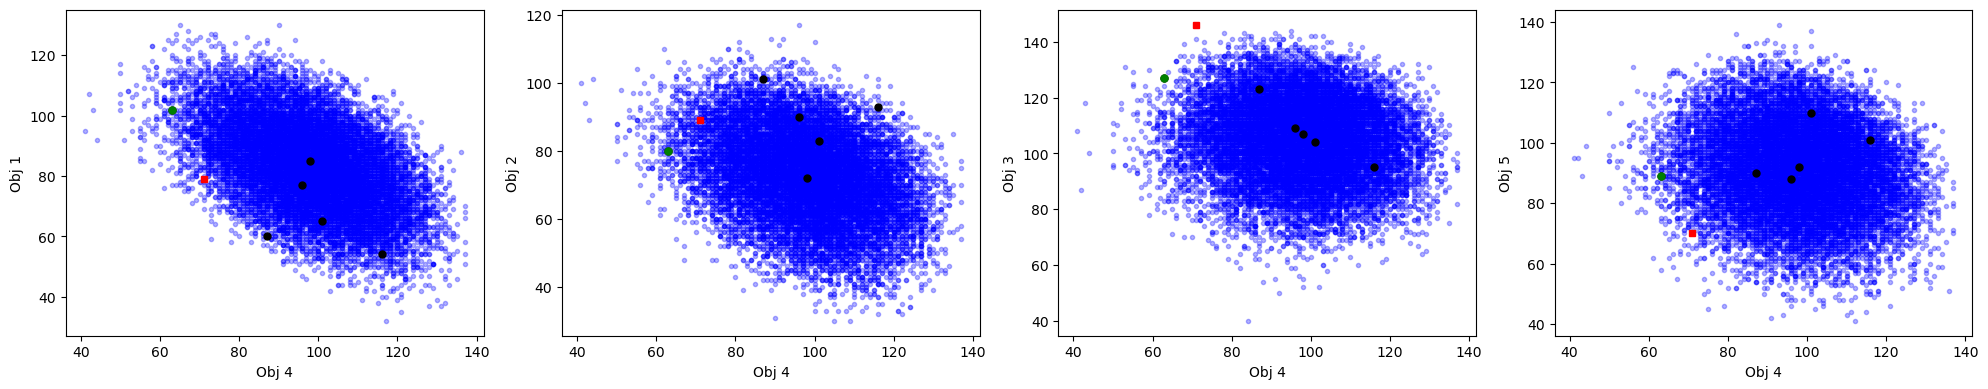

In [48]:
from matplotlib import pyplot as plt

fig = plt.figure(figsize=(20, 4))
ax0 = fig.add_subplot(1, 4, 1)
ax1 = fig.add_subplot(1, 4, 2)
ax2 = fig.add_subplot(1, 4, 3)
ax3 = fig.add_subplot(1, 4, 4)

ax0.plot(pf[:, 3], pf[:, 0], 'bo', alpha=0.3, markersize=3)
ax0.plot(selected_sols[:, 3], selected_sols[:, 0], 'ko', alpha=1, markersize=5)
ax0.plot(new_aspi[3], new_aspi[0], 'go', alpha=1, markersize=5)
ax0.plot(ref_sol[3], ref_sol[0], 'rs', alpha=1, markersize=5)
ax0.set_xlabel('Obj 4')
ax0.set_ylabel('Obj 1')

ax1.plot(pf[:, 3], pf[:, 1], 'bo', alpha=0.3, markersize=3)
ax1.plot(selected_sols[:, 3], selected_sols[:, 1], 'ko', alpha=1, markersize=5)
ax1.plot(new_aspi[3], new_aspi[1], 'go', alpha=1, markersize=5)
ax1.plot(ref_sol[3], ref_sol[1], 'rs', alpha=1, markersize=5)
ax1.set_xlabel('Obj 4')
ax1.set_ylabel('Obj 2')

ax2.plot(pf[:, 3], pf[:, 2], 'bo', alpha=0.3, markersize=3)
ax2.plot(selected_sols[:, 3], selected_sols[:, 2], 'ko', alpha=1, markersize=5)
ax2.plot(new_aspi[3], new_aspi[2], 'go', alpha=1, markersize=5)
ax2.plot(ref_sol[3], ref_sol[2], 'rs', alpha=1, markersize=5)
ax2.set_xlabel('Obj 4')
ax2.set_ylabel('Obj 3')

ax3.plot(pf[:, 3], pf[:, 4], 'bo', alpha=0.3, markersize=3)
ax3.plot(selected_sols[:, 3], selected_sols[:, 4], 'ko', alpha=1, markersize=5)
ax3.plot(new_aspi[3], new_aspi[4], 'go', alpha=1, markersize=5)
ax3.plot(ref_sol[3], ref_sol[4], 'rs', alpha=1, markersize=5)
ax3.set_xlabel('Obj 4')
ax3.set_ylabel('Obj 5')

fig.tight_layout()
plt.show()

In [ ]:
# pick the closet selected solution
dist = np.linalg.norm(selected_sols - ref_sol, axis=1)
new_aspi = selected_sols[dist.argmin()]
## plot

# rank selected solutions and weight
selected_sols_ranked = selected_sols[dist.argsort()]
weights = 1.0 / np.linspace(1, np.exp(2), selected_sols.shape[0])
weights /= weights.sum()
new_aspi = weights @ selected_sols_ranked
## plot

In [ ]:
with open('data/eda_results/history_90_best.pkl', 'rb') as f:
    history = pickle.load(f)

aspi_sol_list = []
selected_sols_list = []

aspi_sol_list = []
for i in range(5):
    history_pass = history[i]
    aspi_sol = history_pass['aspi_solution']
    aspi_sol_list.append(aspi_sol)
    selected_sols = history_pass['selected_solutions']
    selected_sols_list.append(selected_sols)
    dist_to_ref = history_pass['distance_selected_to_ref']

    print("pass: ", i)
    print("aspi_sol: ", aspi_sol)
    print("selected_sols: ", selected_sols)
    print("distance to ref: ", dist_to_ref)

In [ ]:
for i in range(5):
    print("pass: ", i)
    
    with open(f'data/eda_results/eda_human_pass{i}_90_best.pkl', 'rb') as f:
        results = pickle.load(f)
    pf = results["converged_pf_table"][-1]
    dist = np.linalg.norm(pf - ref_sol, axis=1)
    closest_sol = pf[dist.argmin()]
    print("closest_sol: ", closest_sol)
    print("closest_dist: ", dist.min())

    history_pass = history[i]
    aspi_sol = history_pass['aspi_solution']
    dist_to_ref = history_pass['distance_selected_to_ref'].min()
    dist_to_closest = np.linalg.norm(aspi_sol - closest_sol)
    print("aspi_sol: ", aspi_sol)
    print("dist_to_ref: ", dist_to_ref)
    print("dist_to_closest: ", dist_to_closest)
    print('\n')

In [ ]:
ref_sol = np.array([79, 89, 146, 71, 70])

In [ ]:
from matplotlib import pyplot as plt

for i in range(5):
    with open(f'data/eda_results/eda_human_pass{i}_90_best.pkl', 'rb') as f:
        results = pickle.load(f)

    pf = results["converged_pf_table"][-1]

    fig = plt.figure(figsize=(20, 4))
    ax0 = fig.add_subplot(1, 4, 1)
    ax1 = fig.add_subplot(1, 4, 2)
    ax2 = fig.add_subplot(1, 4, 3)
    ax3 = fig.add_subplot(1, 4, 4)

    # ax0.plot(pf_actual[:, 3], pf_actual[:, 0], 'go', alpha=0.5, markersize=3)
    ax0.plot(pf[:, 0], pf[:, 1], 'bo', alpha=0.5, markersize=3)
    ax0.plot(ref_sol[0], ref_sol[1], 'rs', alpha=1, markersize=5)
    ax0.plot(selected_sols_list[i][:, 0], selected_sols_list[i][:, 1], 'ko', alpha=1, markersize=5)
    ax0.plot(aspi_sol_list[i][0], aspi_sol_list[i][1], 'go', alpha=1, markersize=5)
    ax0.set_xlabel('Obj 1')
    ax0.set_ylabel('Obj 2')
    # ax0.set_ylim(30, 120)
    # ax0.set_xlim(35, 125)

    # ax1.plot(pf_actual[:, 3], pf_actual[:, 1], 'go', alpha=0.5, markersize=3)
    ax1.plot(pf[:, 1], pf[:, 2], 'bo', alpha=0.5, markersize=3)
    ax1.plot(ref_sol[1], ref_sol[2], 'rs', alpha=1, markersize=5)
    ax1.plot(selected_sols_list[i][:, 1], selected_sols_list[i][:, 2], 'ko', alpha=1, markersize=5)
    ax1.plot(aspi_sol_list[i][1], aspi_sol_list[i][2], 'go', alpha=1, markersize=5)
    ax1.set_xlabel('Obj 2')
    ax1.set_ylabel('Obj 3')
    # ax1.set_ylim(75, 160)
    # ax1.set_xlim(25, 120)

    # ax2.plot(pf_actual[:, 3], pf_actual[:, 2], 'go', alpha=0.5, markersize=3)
    ax2.plot(pf[:, 2], pf[:, 3], 'bo', alpha=0.5, markersize=3)
    ax2.plot(ref_sol[2], ref_sol[3], 'rs', alpha=1, markersize=5)
    ax2.plot(selected_sols_list[i][:, 2], selected_sols_list[i][:, 3], 'ko', alpha=1, markersize=5)
    ax2.plot(aspi_sol_list[i][2], aspi_sol_list[i][3], 'go', alpha=1, markersize=5)
    ax2.set_xlabel('Obj 3')
    ax2.set_ylabel('Obj 4')
    # ax2.set_ylim(35, 135)
    # ax2.set_xlim(70, 160)

    # ax3.plot(pf_actual[:, 3], pf_actual[:, 4], 'go', alpha=0.5, markersize=3)
    ax3.plot(pf[:, 3], pf[:, 4], 'bo', alpha=0.5, markersize=3)
    ax3.plot(ref_sol[3], ref_sol[4], 'rs', alpha=1, markersize=5)
    ax3.plot(selected_sols_list[i][:, 3], selected_sols_list[i][:, 4], 'ko', alpha=1, markersize=5)
    ax3.plot(aspi_sol_list[i][3], aspi_sol_list[i][4], 'go', alpha=1, markersize=5)
    ax3.set_xlabel('Obj 4')
    ax3.set_ylabel('Obj 5')
    # ax3.set_ylim(35, 125)
    # ax3.set_xlim(35, 140)

    fig.suptitle(f'Pass {i}')
    fig.tight_layout()
    plt.show()